In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



In [192]:
df=pd.read_csv("coca_cola.csv")

In [193]:
df.head(2)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Beverage Brand,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,BevCo,1185732,1/1/2022,Northeast,New York,New York,Coca-Cola,$0.50,"12,000","$6,000","$3,000",50%
1,BevCo,1185732,1/2/2022,Northeast,New York,New York,Diet Coke,$0.50,"10,000","$5,000","$1,500",30%


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   int64 
 2   Invoice Date      9648 non-null   object
 3   Region            9643 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Beverage Brand    9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9643 non-null   object
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   object
 11  Operating Margin  9648 non-null   object
dtypes: int64(1), object(11)
memory usage: 904.6+ KB


In [195]:
df

,Retailer,Retailer ID,Invoice Date,Region,State,City,Beverage Brand,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,BevCo,1185732,1/1/2022,Northeast,New York,New York,Coca-Cola,$0.50,"12,000","$6,000","$3,000",50%
1,BevCo,1185732,1/2/2022,Northeast,New York,New York,Diet Coke,$0.50,"10,000","$5,000","$1,500",30%
2,BevCo,1185732,1/3/2022,Northeast,New York,New York,Sprite,$0.40,"10,000","$4,000","$1,400",35%
3,BevCo,1185732,1/4/2022,Northeast,New York,New York,Fanta,$0.45,"8,500","$3,825","$1,339",35%
4,BevCo,1185732,1/5/2022,Northeast,New York,New York,Powerade,$0.60,"9,000","$5,400","$1,620",30%
...,...,...,...,...,...,...,...,...,...,...,...,...
9643,BevCo,1185732,1/24/2023,Northeast,New Hampshire,Manchester,Powerade,$0.50,640,$320,$90,28%
9644,BevCo,1185732,1/24/2023,Northeast,New Hampshire,Manchester,Dasani Water,$0.41,"1,050",$431,$138,32%
9645,BevCo,1185732,2/22/2023,Northeast,New Hampshire,Manchester,Coca-Cola,$0.41,"1,840",$754,$279,37%
9646,BevCo,1185732,2/22/2023,Northeast,New Hampshire,Manchester,Diet Coke,$0.42,700,$294,$123,42%


In [196]:
#removing the unnecessary column , like "Retailer ID" , Retailer ID is not going to help to build our model
df.drop(columns='Retailer ID', inplace=True)

In [197]:
df.sample()

,Retailer,Invoice Date,Region,State,City,Beverage Brand,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
9064,BevCo,1/9/2023,Southeast,Georgia,Atlanta,Diet Coke,$0.30,"2,560",$768,$307,40%


In [198]:
df.dtypes

,0
Retailer,object
Invoice Date,object
Region,object
State,object
City,object
Beverage Brand,object
Price per Unit,object
Units Sold,object
Total Sales,object
Operating Profit,object


In [199]:
# conver the 'Invoice Date' column  into the date_time format
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.month
df['Day'] = df['Invoice Date'].dt.day

In [200]:
df.dtypes

,0
Retailer,object
Invoice Date,datetime64[ns]
Region,object
State,object
City,object
Beverage Brand,object
Price per Unit,object
Units Sold,object
Total Sales,object
Operating Profit,object


In [201]:
# as we extract the all date_time information , we have to drop the original column
df.drop(columns=['Invoice Date'], inplace=True)


In [202]:
# convert these column ("Price per Unit", "Units Sold", "Total Sales", "Operating Profit) into numerical column
for col in ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit","Operating Margin"]:
    df[col] = df[col].replace('[\$,%]', '', regex=True).astype(float)

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Retailer          9648 non-null   object 
 1   Region            9643 non-null   object 
 2   State             9648 non-null   object 
 3   City              9648 non-null   object 
 4   Beverage Brand    9648 non-null   object 
 5   Price per Unit    9648 non-null   float64
 6   Units Sold        9643 non-null   float64
 7   Total Sales       9648 non-null   float64
 8   Operating Profit  9648 non-null   float64
 9   Operating Margin  9648 non-null   float64
 10  Year              9648 non-null   int32  
 11  Month             9648 non-null   int32  
 12  Day               9648 non-null   int32  
dtypes: float64(5), int32(3), object(5)
memory usage: 866.9+ KB


In [204]:
# to see the where are the null values
df.isnull().sum()

,0
Retailer,0
Region,5
State,0
City,0
Beverage Brand,0
Price per Unit,0
Units Sold,5
Total Sales,0
Operating Profit,0
Operating Margin,0


In [205]:
# In two column("Region","Units Sold") there are null values , then we should replace the null values with median for numerical column and mode for categorical column
df["Units Sold"]= df["Units Sold"].fillna(df["Units Sold"].median())
df["Region"]=df["Region"].fillna(df["Region"].mode()[0])

In [206]:
df.isnull().sum()
# now all null values are removed

,0
Retailer,0
Region,0
State,0
City,0
Beverage Brand,0
Price per Unit,0
Units Sold,0
Total Sales,0
Operating Profit,0
Operating Margin,0


In [207]:
df["Operating Margin"].unique()

array([50., 30., 35., 25., 45., 20., 15., 40., 55., 10., 60., 65., 61.,
       42., 46., 37., 62., 44., 47., 49., 43., 38., 63., 41., 64., 48.,
       36., 39., 58., 59., 57., 31., 28., 27., 51., 66., 33., 34., 29.,
       24., 23., 21., 52., 53., 68., 69., 67., 54., 56., 70., 74., 26.,
       76., 77., 73., 32., 75., 72., 71., 80., 79., 22., 19., 17., 18.,
       12.])

In [208]:
# I want to change this column into label , like <30 as low , or 30 to 50 as modarate , 50 to 60 as good , > 60 as high

df['Operating_Margin_Label'] = pd.cut(df['Operating Margin'],bins=[0, 30, 50, 60, float('inf')],labels=['Very Low', 'Moderate', 'Good', 'High'],right=False)


In [209]:
df.drop(columns= "Operating Margin",inplace=True)

In [210]:
df.dtypes

,0
Retailer,object
Region,object
State,object
City,object
Beverage Brand,object
Price per Unit,float64
Units Sold,float64
Total Sales,float64
Operating Profit,float64
Year,int32


In [211]:
# Lets under stand the data through visulisation
df.columns

Index(['Retailer', 'Region', 'State', 'City', 'Beverage Brand',
       'Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit',
       'Year', 'Month', 'Day', 'Operating_Margin_Label'],
      dtype='object')

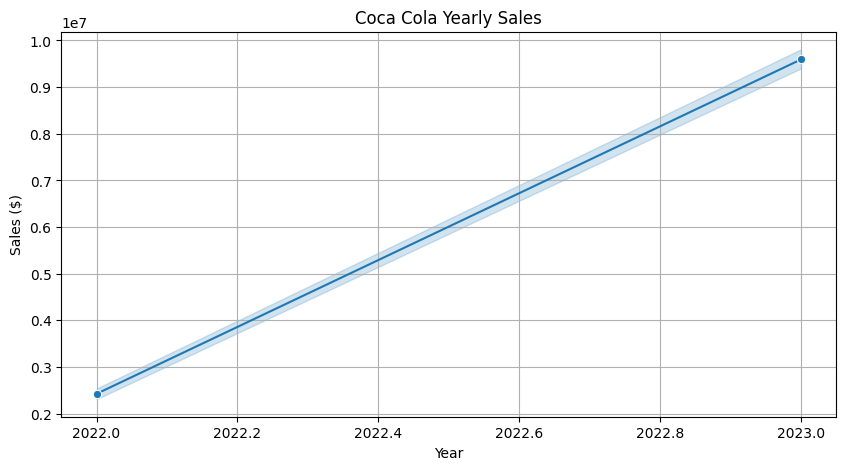

In [212]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Year",y="Total Sales",data = df,estimator='sum' ,marker='o')
plt.title('Coca Cola Yearly Sales')
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid()

# We can see , with year increasing , the sales is increasing

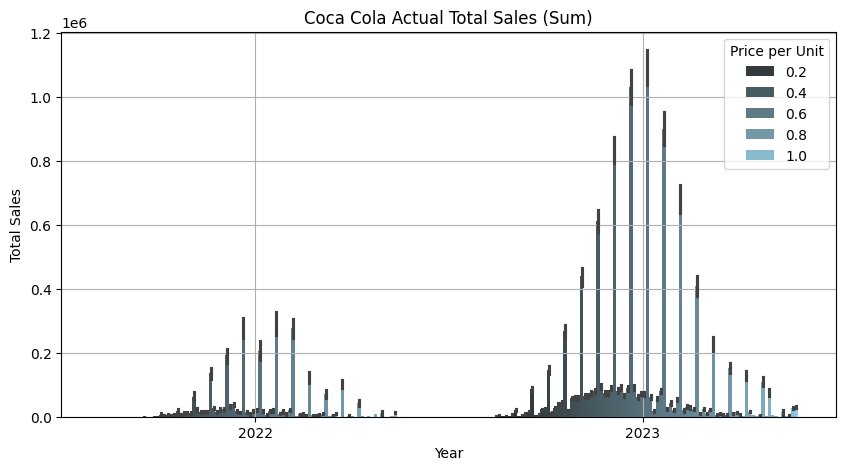

In [213]:
plt.figure(figsize=(10,5))
sns.barplot(x="Year", y="Total Sales", data=df,hue='Price per Unit',estimator='sum', color="skyblue")
plt.title('Coca Cola Actual Total Sales (Sum)')
plt.grid()
plt.show()
# we can see in 2023 , the Sales is too much increased

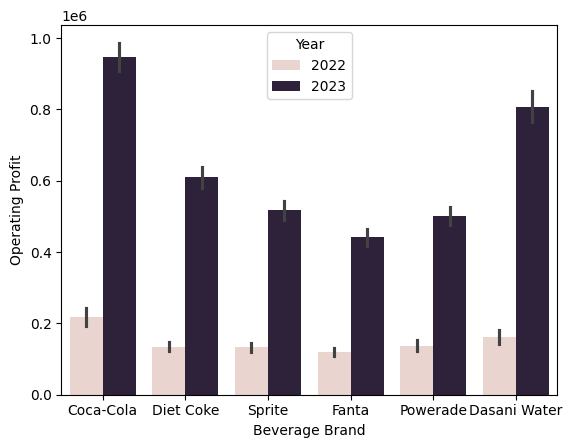

In [214]:
plt.figure()
sns.barplot(x='Beverage Brand',y='Operating Profit',hue="Year", estimator='sum',data=df)
plt.show()
# cocacola and Dasani water getting the more profit

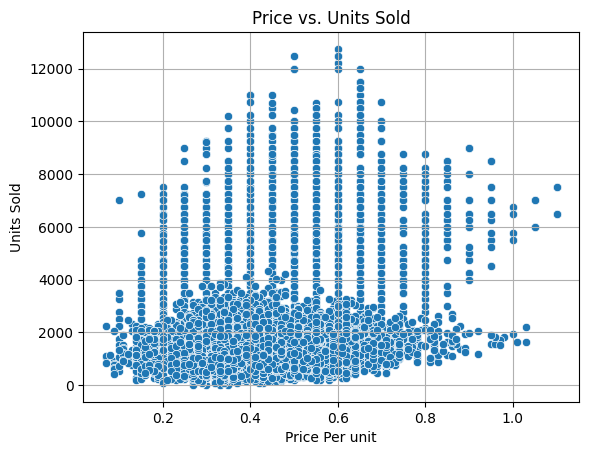

In [215]:
sns.scatterplot(x=df['Price per Unit'], y=df['Units Sold'])
plt.title("Price vs. Units Sold")
plt.xlabel("Price Per unit")
plt.ylabel("Units Sold")
plt.grid(True)
# We can see with increasing the price , actually selling is also slightly decreasing

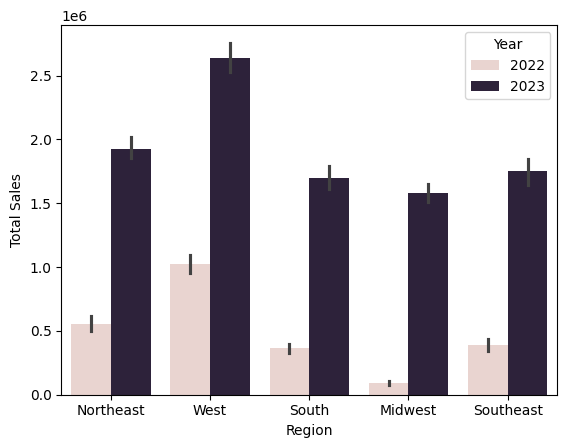

In [216]:
plt.figure()
sns.barplot(x='Region',y='Total Sales', data=df,estimator='sum',hue="Year")
plt.show()
# we can see for every region Total sales is decreases

Text(0.5, 1.0, 'Correlation Matrix of Key Sales Metrics')

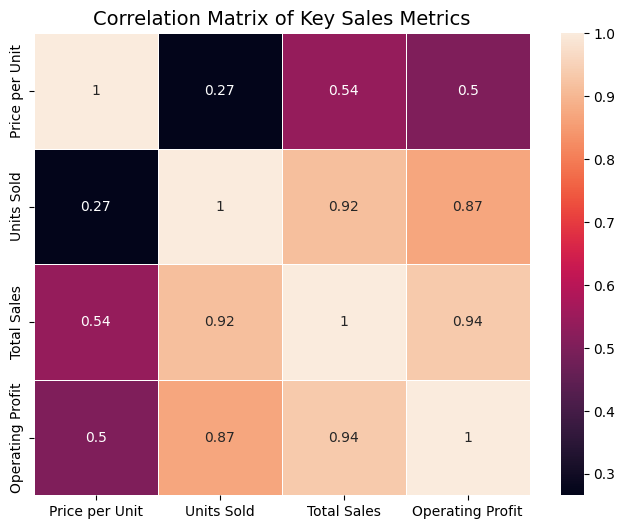

In [217]:
correlation_matrix = df[["Price per Unit", "Units Sold", "Total Sales", "Operating Profit"]].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True,linewidths=0.5)

plt.title("Correlation Matrix of Key Sales Metrics", fontsize=14)

In [218]:
ncity_year=df.groupby("Year")["City"].nunique()
ncity_year


,City
Year,
2022,9
2023,45


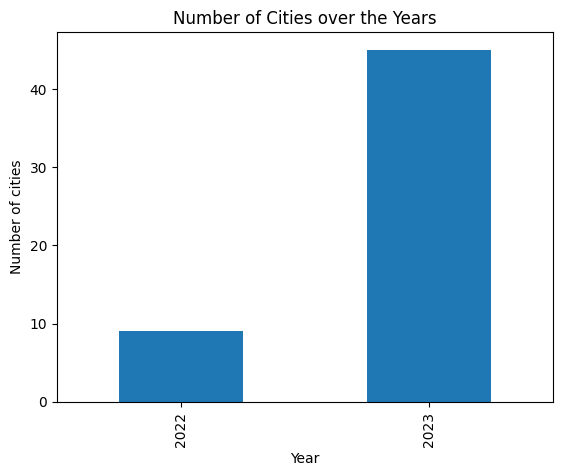

In [219]:
plt.figure()
ncity_year.plot(kind='bar')
plt.title("Number of Cities over the Years")
plt.xlabel("Year")
plt.ylabel("Number of cities")
plt.show()

In [221]:
df.dtypes

,0
Retailer,object
Region,object
State,object
City,object
Beverage Brand,object
Price per Unit,float64
Units Sold,float64
Total Sales,float64
Operating Profit,float64
Year,int32


In [222]:
# lets remove the Outlier
numerical_column=['Price per Unit','Units Sold','Total Sales','Operating Profit']
for i in numerical_column:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  LF=Q1-1.5*IQR
  UF=Q3+1.5*IQR
  df=df[(df[i] >=LF) & (df[i]<=UF)]

In [223]:
df.columns

Index(['Retailer', 'Region', 'State', 'City', 'Beverage Brand',
       'Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit',
       'Year', 'Month', 'Day', 'Operating_Margin_Label'],
      dtype='object')

In [224]:
# lets do feature engineering >> New features from old fetures
df["Expense"]=df["Total Sales"]- df["Operating Profit"]

In [225]:
# Encoding for Nominal Categorical column > But first see the number of unique elements in Categorical column , Otherwise it will increase the complexcity

categorical=['Retailer', 'Region', 'State', 'City', 'Beverage Brand']
for i in categorical:
  print("Total unique value in ", i , "is",df[i].nunique())

Total unique value in  Retailer is 6
Total unique value in  Region is 5
Total unique value in  State is 50
Total unique value in  City is 52
Total unique value in  Beverage Brand is 6


In [226]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['State', 'City'])

df_encoded = encoder.fit_transform(df[['State', 'City']], df['Total Sales'])

df['State_Encoded'] = df_encoded['State']
df['City_Encoded'] = df_encoded['City']
df.drop(['State', 'City'], axis=1, inplace=True)

In [227]:
# Do ordinal encoding >> one hot encoding for rest column
lcategorical = ['Retailer', 'Region', 'Beverage Brand']
df = pd.get_dummies(df, columns=lcategorical, drop_first=True)

In [228]:
df.dtypes

,0
Price per Unit,float64
Units Sold,float64
Total Sales,float64
Operating Profit,float64
Year,int32
Month,int32
Day,int32
Operating_Margin_Label,category
Expense,float64
State_Encoded,float64


In [230]:
df.Operating_Margin_Label.unique()

['Moderate', 'Good', 'Very Low', 'High']
Categories (4, object): ['Very Low' < 'Moderate' < 'Good' < 'High']

In [231]:
mapping = {
    'Very Low': 0,
    'Moderate': 1,
    'Good': 2,
    'High': 3
    }
df['Operating_Margin'] = df['Operating_Margin_Label'].map(mapping)
df.drop(columns="Operating_Margin_Label")

,Price per Unit,Units Sold,Total Sales,Operating Profit,Year,Month,Day,Expense,State_Encoded,City_Encoded,...,Region_Northeast,Region_South,Region_Southeast,Region_West,Beverage Brand_Dasani Water,Beverage Brand_Diet Coke,Beverage Brand_Fanta,Beverage Brand_Powerade,Beverage Brand_Sprite,Operating_Margin
72,0.40,5500.0,2200.0,660.0,2022,7,23,1540.0,844.379747,884.852115,...,False,True,False,False,False,False,False,True,False,1
78,0.40,5000.0,2000.0,600.0,2022,7,29,1400.0,844.379747,884.852115,...,False,True,False,False,False,False,False,True,False,1
84,0.45,5000.0,2250.0,675.0,2022,8,4,1575.0,844.379747,884.852115,...,False,True,False,False,False,False,False,True,False,1
90,0.45,5250.0,2363.0,709.0,2022,8,10,1654.0,844.379747,884.852115,...,False,True,False,False,False,False,False,True,False,1
126,0.45,5750.0,2588.0,776.0,2022,9,15,1812.0,844.379747,884.852115,...,False,True,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,0.50,640.0,320.0,90.0,2023,1,24,230.0,823.762886,823.762886,...,True,False,False,False,False,False,False,True,False,0
9644,0.41,1050.0,431.0,138.0,2023,1,24,293.0,823.762886,823.762886,...,True,False,False,False,True,False,False,False,False,1
9645,0.41,1840.0,754.0,279.0,2023,2,22,475.0,823.762886,823.762886,...,True,False,False,False,False,False,False,False,False,1
9646,0.42,700.0,294.0,123.0,2023,2,22,171.0,823.762886,823.762886,...,True,False,False,False,False,True,False,False,False,1


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8106 entries, 72 to 9647
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Price per Unit               8106 non-null   float64 
 1   Units Sold                   8106 non-null   float64 
 2   Total Sales                  8106 non-null   float64 
 3   Operating Profit             8106 non-null   float64 
 4   Year                         8106 non-null   int32   
 5   Month                        8106 non-null   int32   
 6   Day                          8106 non-null   int32   
 7   Operating_Margin_Label       8106 non-null   category
 8   Expense                      8106 non-null   float64 
 9   State_Encoded                8106 non-null   float64 
 10  City_Encoded                 8106 non-null   float64 
 11  Retailer_BevCo               8106 non-null   bool    
 12  Retailer_FizzyCo             8106 non-null   bool    
 13  Retaile

In [246]:
# Now our data in ready For model